In [34]:
# Install required libraries
!pip install tensorflow --quiet
!pip install opencv-python --quiet
!pip install matplotlib --quiet
!pip install scikit-learn --quiet

In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

from sklearn.metrics import confusion_matrix, classification_report

In [36]:
!git clone https://github.com/prernarohra/Fake-Currency-Checker.git

fatal: destination path 'Fake-Currency-Checker' already exists and is not an empty directory.


In [37]:
!ls Fake-Currency-Checker

 Deploy.py			      Fake-currency.keras	 README.md
'Fake Currency Detection.ipynb'      'Indian Currency Dataset'
'Fake Currency Detection Video.mp4'   LICENSE


In [38]:
dataset_path = "Fake-Currency-Checker/Indian Currency Dataset"

In [39]:
import os

for root, dirs, files in os.walk(dataset_path):
    print(root, len(files))

Fake-Currency-Checker/Indian Currency Dataset 3
Fake-Currency-Checker/Indian Currency Dataset/train 0
Fake-Currency-Checker/Indian Currency Dataset/train/real 73
Fake-Currency-Checker/Indian Currency Dataset/train/fake 77
Fake-Currency-Checker/Indian Currency Dataset/validation 0
Fake-Currency-Checker/Indian Currency Dataset/validation/real 29
Fake-Currency-Checker/Indian Currency Dataset/validation/fake 31
Fake-Currency-Checker/Indian Currency Dataset/test 0
Fake-Currency-Checker/Indian Currency Dataset/test/real 48
Fake-Currency-Checker/Indian Currency Dataset/test/fake 59


In [40]:
train_dir = "Fake-Currency-Checker/Indian Currency Dataset/train"
val_dir = "Fake-Currency-Checker/Indian Currency Dataset/validation"
test_dir = "Fake-Currency-Checker/Indian Currency Dataset/test"

In [111]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [112]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='binary'
)


Found 150 images belonging to 2 classes.


In [113]:
val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='binary'
)

Found 60 images belonging to 2 classes.


In [114]:
test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

Found 107 images belonging to 2 classes.


In [115]:
print(train_data.class_indices)

{'fake': 0, 'real': 1}


In [116]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

cnn_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [117]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [118]:
history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=40
)

Epoch 1/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.5133 - loss: 0.8632 - val_accuracy: 0.5833 - val_loss: 0.6640
Epoch 2/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.4800 - loss: 0.7222 - val_accuracy: 0.6333 - val_loss: 0.6739
Epoch 3/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.6267 - loss: 0.6566 - val_accuracy: 0.7333 - val_loss: 0.5557
Epoch 4/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.7133 - loss: 0.5887 - val_accuracy: 0.7333 - val_loss: 0.5554
Epoch 5/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.7400 - loss: 0.5431 - val_accuracy: 0.7500 - val_loss: 0.5420
Epoch 6/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.7533 - loss: 0.5444 - val_accuracy: 0.7333 - val_loss: 0.5325
Epoch 7/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.7467 - loss: 0.5095 - val_accuracy: 0.7500 - val_loss: 0.5221
Epoch 8/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.7533 - loss: 0.5003 - val_accuracy: 0.7833 - val_loss:

In [135]:
cnn_loss , cnn_acc = cnn_model.evaluate(test_data)

print("MobileNet Accuracy:", cnn_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 689ms/step - accuracy: 0.8785 - loss: 0.6747
MobileNet Accuracy: 0.8785046935081482


In [119]:
predictions_cnn = cnn_model.predict(test_data)
predicted_classes_cnn = (predictions_cnn > 0.5).astype(int)
predicted_classes_cnn = predicted_classes_cnn.flatten()
true_classes_cnn = test_data.classes
cm_cnn = confusion_matrix(true_classes_cnn, predicted_classes_cnn)
print(cm_cnn)

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 663ms/step
[[46 13]
 [ 0 48]]


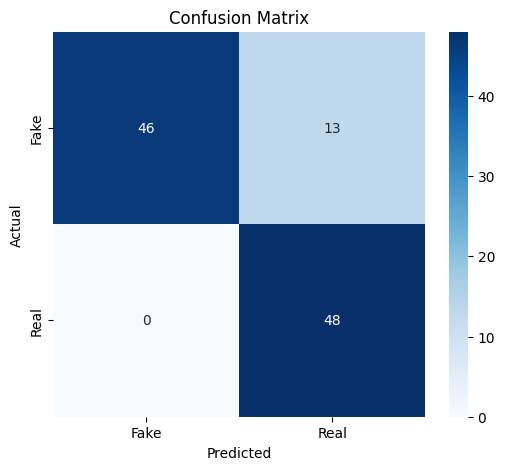

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6,5))

sns.heatmap(cm_cnn,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Fake","Real"],
            yticklabels=["Fake","Real"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

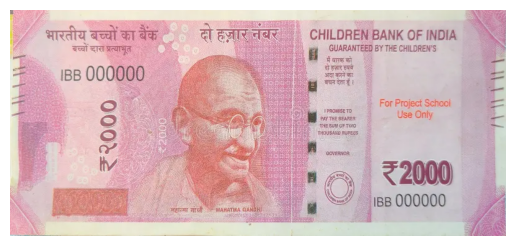

In [ ]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = "test_img2.webp"

# Load the image
img = image.load_img(img_path)

# Display the image
plt.imshow(img)
plt.axis('off') # Hide axes
plt.show()

In [122]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "test_img2.webp"

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255

prediction = cnn_model.predict(img_array)

if prediction > 0.5:
    print("Real Currency")
else:
    print("Fake Currency")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Real Currency


In [123]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [124]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

In [57]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

output = Dense(1, activation='sigmoid')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=output)

In [58]:
mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [126]:
history_mobilenet = mobilenet_model.fit(
    train_data,
    epochs=40,
    validation_data=val_data
)

Epoch 1/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9333 - loss: 0.1529 - val_accuracy: 0.9500 - val_loss: 0.2211
Epoch 2/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9733 - loss: 0.1028 - val_accuracy: 0.9500 - val_loss: 0.1540
Epoch 3/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9333 - loss: 0.1680 - val_accuracy: 0.9667 - val_loss: 0.1694
Epoch 4/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9667 - loss: 0.1282 - val_accuracy: 0.8833 - val_loss: 0.2256
Epoch 5/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9200 - loss: 0.1852 - val_accuracy: 0.9333 - val_loss: 0.1438
Epoch 6/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9467 - loss: 0.1505 - val_accuracy: 0.9500 - val_loss: 0.1770
Epoch 7/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9733 - loss: 0.1251 - val_accuracy: 0.9333 - val_loss: 0.1834
Epoch 8/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9600 - loss: 0.1230 - val_accuracy: 0.9000 - val_loss:

In [127]:
mobilenet_loss, mobilenet_acc = mobilenet_model.evaluate(test_data)

print("MobileNet Accuracy:", mobilenet_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 711ms/step - accuracy: 0.9720 - loss: 0.1153
MobileNet Accuracy: 0.9719626307487488


In [128]:
predictions_mob = mobilenet_model.predict(test_data)
predicted_classes_mob = (predictions_mob > 0.5).astype(int)
predicted_classes_mob = predicted_classes_mob.flatten()
true_classes_mob = test_data.classes
cm_mob = confusion_matrix(true_classes_mob, predicted_classes_mob)
print(cm_mob)

7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step
[[56  3]
 [ 0 48]]


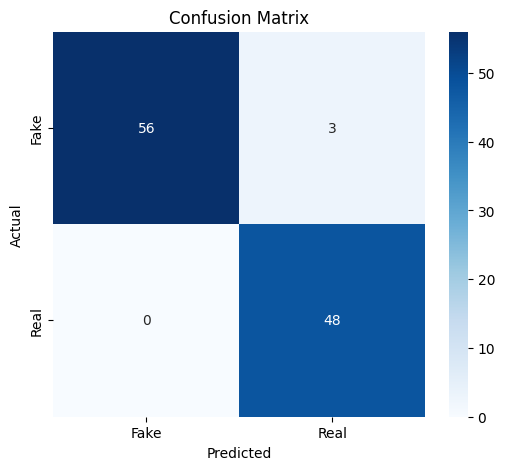

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(cm_mob,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Fake","Real"],
            yticklabels=["Fake","Real"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

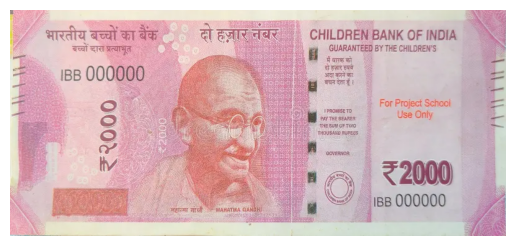

In [133]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = "test_img2.webp"

# Load the image
img = image.load_img(img_path)

# Display the image
plt.imshow(img)
plt.axis('off') # Hide axes
plt.show()

In [134]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "test_img2.webp"

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255

prediction = mobilenet_model.predict(img_array)

if prediction > 0.5:
    print("Real Currency")
else:
    print("Fake Currency")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Fake Currency
